In [ ]:
import sys 
from minusface import MinusBackbone
model = MinusBackbone(mode='stage1') 

/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from PIL import Image
import numpy as np
def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [3]:
import torch
ckpt_path = "../../../../minusface_stage1.pth"
model.load_state_dict(torch.load(ckpt_path, map_location='cpu'))

<All keys matched successfully>

In [4]:
test_id = 19
img_path = f"/path/to/FaceLinkGen/original_face/{test_id:04d}.png"
# img_path = f"/path/to/FaceLinkGen/original_face/{test_id:04d}.png"

In [5]:
# from insightface.app import FaceAnalysis

# app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider'])
# app.prepare(ctx_id=0, det_size=(128, 128))

In [6]:
# import cv2
# def is_same_person(img1_path, img2_path, threshold=0.3, model="buffalo_l"):
#     def get_embedding(path):
#         img = cv2.imread(path)
#         img = cv2.resize(img, (128,128))
#         for det_thresh in np.arange(0.4, -0.01, -0.01):
#             app.det_model.det_thresh = det_thresh
#             faces = app.get(img, max_num=8)
#             max_area = 0
#             max_area_idx = 0
#             for idx, face in enumerate(faces):
#                 box = face.bbox 
#                 area = (box[2] - box[0]) * (box[3] - box[1])
#                 if area > max_area:
#                     max_area = area
#                     max_area_idx = idx
#             if len(faces) == 0:
#                 continue
#             else:
#                 break
#         return faces[max_area_idx].normed_embedding
#     emb1, emb2 = get_embedding(img1_path), get_embedding(img2_path)

#     sim = float(np.dot(emb1, emb2))
#     return {
#        "distance": 1 - sim,
#        "emb1": emb1,
#        "emb2": emb2
#     }

In [7]:
def preprocess_image(image_path):
    from PIL import Image
    from torchvision import transforms

    input_image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
    input_tensor = preprocess(input_image)
    input_batch = input_tensor.unsqueeze(0)  # Create a mini-batch as expected by the model
    return input_batch

In [8]:
preprocess_image(img_path).shape

torch.Size([1, 3, 112, 112])

In [9]:
model = model.eval()
model = model.to('cuda')

In [24]:
img_path = img_path.replace("0019", "0018")

In [29]:
img_path

'/path/to/FaceLinkGen/original_face/0018.png'

In [41]:
f1 = model(preprocess_image(img_path.replace("0018", "0018")).to('cuda'))[6]
f2 = model(preprocess_image(img_path.replace("original_face", "original_pair_face").replace("0018", "0018")).to('cuda'))[6]
torch.nn.functional.cosine_similarity(f1, f2) 

torch.Size([1, 192, 112, 112])
torch.Size([1, 192, 112, 112])


tensor([0.2916], device='cuda:0', grad_fn=<SumBackward1>)

tensor([0.2075], device='cuda:0', grad_fn=<SumBackward1>)

In [ ]:
# this is to match with real photo, not matching with another redisual

In [ ]:
import os
import tqdm
os.makedirs("./results", exist_ok=True)
os.makedirs("./results_pair", exist_ok=True)            
root_path = "./original_face"
image_paths = [os.path.join(root_path, f) for f in os.listdir(root_path) if f.endswith('.png')]
db_embeddings = []
query_embeddings = [] 
with torch.no_grad():
    for img_path in tqdm.tqdm(image_paths):
        res = model(preprocess_image(img_path).to('cuda'))
        img = res[5].detach().cpu()[0].permute(1, 2, 0).numpy()
        from PIL import Image
        img = (img - img.min()) / (img.max() - img.min())
        img_pil = Image.fromarray((img * 255).astype('uint8').squeeze()) 
        img_pil.save("./results/" + os.path.basename(img_path))
        ret = is_same_person(img_path, "./results/" + os.path.basename(img_path))

        res_pair = model(preprocess_image(img_path.replace("original_face", "original_pair_face")).to('cuda'))
        img_pair = res_pair[5].detach().cpu()[0].permute(1, 2, 0).numpy()
        from PIL import Image
        img_pair = (img_pair - img_pair.min()) / (img_pair.max() - img_pair.min())
        img_pil_pair = Image.fromarray((img_pair * 255).astype('uint8').squeeze()) 
        img_pil_pair.save("./results_pair/" + os.path.basename(img_path))
# bozitaileikelknweismzheyangfanerbuhaodoushichadetezheng zhuanmenxunlain
        ret = is_same_person("./results_pair/" + os.path.basename(img_path), "./results/" + os.path.basename(img_path))
        print(f"{img_path} distance: {ret['distance']}")
        db_embeddings.append(ret["emb1"]) 
        query_embeddings.append(ret["emb2"])

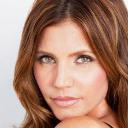

In [ ]:
Image.open(img_path.replace("original_face", "original_pair_face"))

In [8]:
from deepface import DeepFace
test_id = 1
result = DeepFace.verify(
      img1_path = f"./results_pair/{test_id+10:04d}.png",
      img2_path = f"./results/{test_id:04d}.png",
      enforce_detection=False, 
      model_name="Facenet"
) 
result

{'verified': True,
 'distance': 0.073789,
 'threshold': 0.4,
 'confidence': 100,
 'model': 'Facenet',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 0,
   'y': 0,
   'w': 111,
   'h': 111,
   'left_eye': None,
   'right_eye': None},
  'img2': {'x': 0,
   'y': 0,
   'w': 111,
   'h': 111,
   'left_eye': None,
   'right_eye': None}},
 'time': 0.49}

In [34]:
import os
test_id = 17
dis = []
for delta in range(0, 30):
      if not os.path.exists(f"./results_pair/{test_id+delta:04d}.png"):
          continue
      dis.append(is_same_person(
            img1_path = f"./results_pair/{test_id+delta:04d}.png",
            img2_path = f"./results/{test_id:04d}.png",
      )["distance"])

In [58]:
# import sys
# sys.path.insert(0, "../../")
# from torchkit.backbone import get_model   
# recognizer = get_model('IR_18')([112, 112])
# recognizer = recognizer.eval() 
# embeddings_1 = recognizer(preprocess_image(f"./results_pair/{test_id:04d}.png")) 
# embeddings_2 = recognizer(preprocess_image(f"./results/{test_id:04d}.png")) 
# import torch
# torch.nn.functional.cosine_similarity(embeddings_1, embeddings_2)

tensor([0.7480], grad_fn=<SumBackward1>)

tensor([0.7947], grad_fn=<SumBackward1>)

In [59]:
is_same_person(
            img1_path = f"./results_pair/{test_id:04d}.png",
            img2_path = f"./results/{test_id:04d}.png",
)["distance"]

1.0189598202705383

In [38]:
np.where(np.argsort(dis)==0)[0]/len(dis)

array([0.79310345])

In [5]:
result = DeepFace.verify(
      img1_path = f"./original_face/{test_id:04d}.png",
      img2_path = f"./original_pair_face/{test_id:04d}.png",
      enforce_detection=False, 
      model_name="OpenFace"
) 
result

{'verified': True,
 'distance': 0.081067,
 'threshold': 0.1,
 'confidence': 59.96,
 'model': 'OpenFace',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 18,
   'y': 22,
   'w': 97,
   'h': 97,
   'left_eye': (81, 60),
   'right_eye': (43, 58)},
  'img2': {'x': 16,
   'y': 22,
   'w': 98,
   'h': 98,
   'left_eye': (82, 60),
   'right_eye': (43, 59)}},
 'time': 0.35}

In [ ]:
from deepface import DeepFace


In [27]:
image_paths[0]

'./original_face/0510.png'

In [30]:
import pickle
with open("./results/embeddings_2.pkl", "wb") as f:
    pickle.dump({
        "db": np.array(db_embeddings),
        "query": np.array(query_embeddings)
    }, f)

In [ ]:
res[1].shape 

torch.Size([1, 3, 112, 112])

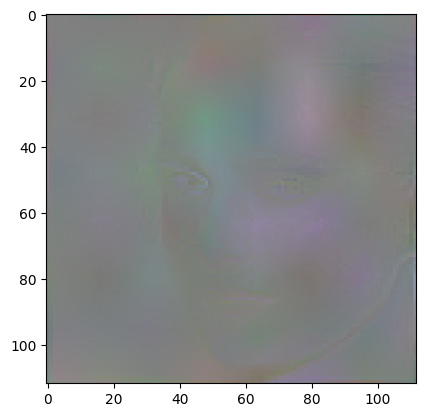

In [ ]:
import pylab 
img = res[5].detach().cpu()[0].permute(1, 2, 0).numpy()
from PIL import Image
img_pil = Image.fromarray((img * 255).astype('uint8').squeeze())
# img_pil = img_pil.resize((256, 256), Image.BILINEAR)
img_pil.save("residue_map.png")
# img = res[5][:].mean(dim=1).unsqueeze(1).detach().cpu()[0].permute(1, 2, 0).numpy()
# img = (img - img.min()) / (img.max() - img.min())
# pylab.imshow(img)
# pylab.show()  

In [ ]:
from deepface import DeepFace


2025-11-22 22:38:31.353213: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-22 22:38:31.508372: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-22 22:38:32.106626: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/cv2/../../lib64:/home/

{'verified': True,
 'distance': 0.044605,
 'threshold': 0.4,
 'confidence': 100,
 'model': 'Facenet',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 0,
   'y': 0,
   'w': 111,
   'h': 111,
   'left_eye': None,
   'right_eye': None},
  'img2': {'x': 0,
   'y': 0,
   'w': 111,
   'h': 111,
   'left_eye': None,
   'right_eye': None}},
 'time': 0.5}

In [ ]:
import sys
sys.path.insert(0, "../../")
from torchkit.backbone import get_model

In [ ]:
import wandb
wandb.init(project="minusface")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: wguo6358 (3dsmile). Use `wandb login --relogin` to force relogin


In [ ]:
image_paths

NameError: name 'image_paths' is not defined

In [ ]:
from deepface import DeepFace
ranks = []
for test_id in range(1, len(os.listdir("/path/to/FaceLinkGen/original_pair_face/"))-1):
  dis = []
  result = DeepFace.verify(
      img1_path = "residue_map.png", 
      img2_path = f"./results/{test_id:04d}.png",
      enforce_detection=False, 
  )
  dis.append(result["distance"])
  print(dis[-1]) 
  import os
  import tqdm
  import numpy as np
  # for image_name in tqdm.tqdm(sorted(os.listdir("/path/to/FaceLinkGen/original_face/"))):
  for image_name in tqdm.tqdm(sorted(os.listdir("/path/to/FaceLinkGen/original_pair_face/"))):
    if image_name == f"{test_id:04d}.png":
      continue
    img2_path = f"/path/to/FaceLinkGen/original_pair_face/{image_name}"
    img1_path = f"./results_pair/{test_id:04d}.png" 
    print(img1_path, img2_path)
    result = DeepFace.verify(
      img1_path = img1_path,  
      img2_path = img2_path,
      enforce_detection=False, 
    )
    dis.append(result["distance"])  
    # print(f"{image_name}: {result['distance']}") 
    wandb.log({"distance_rank": np.where(np.argsort(dis)==0)[0]/len(dis)})
  ranks.append(np.where(np.argsort(dis)==0)[0][0] / len(dis))
  wandb.log({"final_rank": ranks[-1]}) 
  print(f"final rank: {ranks[-1]}")

0.102096


  0%|          | 0/968 [00:00<?, ?it/s]

./results/0001.png /path/to/FaceLinkGen/original_pair_face/0002.png


  0%|          | 2/968 [00:00<03:59,  4.03it/s]

./results/0001.png /path/to/FaceLinkGen/original_pair_face/0003.png


...

  4%|▍         | 40/968 [00:20<07:53,  1.96it/s]

./results/0001.png /path/to/FaceLinkGen/original_pair_face/0041.png


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x70fc80117710>> (for post_run_cell):


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
np.argsort(sim)[::-1]==4

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False])